# Thompson Sampling — OpenAssistant Conversations

This notebook trains Thompson Sampling on a customer service environment
modeled after the **OpenAssistant (oasst1)** dataset.

From our EDA: OpenAssistant has **161K messages across 66K conversation trees** with
**461K quality annotations** (human ratings!). Users are generally cooperative and the
focus is on response quality rather than urgent problem-solving.

Simulator settings: neutral sentiment, low frustration, easier resolution threshold, max 15 turns.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

from environment import CustomerServiceEnv

print('imports done!')

imports done!


## Setting up the Environment

In [18]:
env = CustomerServiceEnv(dataset='openassistant')

print(f'Environment: {env.dataset_name}')
print(f'Max turns: {env.max_turns}')
print(f'Initial sentiment: {env.initial_sentiment}')
print(f'Initial frustration: {env.initial_frustration} (users are cooperative here)')
print(f'Resolution threshold: {env.resolution_threshold} (lower = easier to resolve)')
print(f'Actions: {env.ACTIONS}')

Environment: OpenAssistant Conversations
Max turns: 15
Initial sentiment: 0.5
Initial frustration: 0.2 (users are cooperative here)
Resolution threshold: 0.5 (lower = easier to resolve)
Actions: ['ask_info', 'provide_solution', 'empathize', 'escalate', 'close']


## Random baseline

In [19]:
state = env.reset()
total_reward = 0
print('--- Random Agent on OpenAssistant Environment ---')
print(f'Customer: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
print()

while not env.done:
    action = random.randint(0, env.NUM_ACTIONS - 1)
    next_state, reward, done, outcome = env.step(action)
    total_reward += reward
    env.render(action)
    state = next_state

print(f'\nTotal reward: {total_reward:.2f} | Outcome: {outcome}')

--- Random Agent on OpenAssistant Environment ---
Customer: sentiment=0.55, frustration=0.24

  Turn  1 | Action: provide_solution
    Sentiment: 0.55 | Frustration: 0.24 | Info: 0.00
    >> Outcome: resolved

Total reward: 2.90 | Outcome: resolved


## Thompson Sampling Agent

In [20]:
class ThompsonSamplingAgent:
    
    def __init__(self, n_actions=5, n_bins=4):
        self.n_actions = n_actions
        self.n_bins = n_bins
        self.n_contexts = n_bins * n_bins
        self.alpha = np.ones((self.n_contexts, n_actions))
        self.beta_param = np.ones((self.n_contexts, n_actions))
    
    def _get_context(self, state):
        sent_bin = min(int(state[0] * self.n_bins), self.n_bins - 1)
        frust_bin = min(int(state[1] * self.n_bins), self.n_bins - 1)
        return sent_bin * self.n_bins + frust_bin
    
    def choose_action(self, state):
        ctx = self._get_context(state)
        samples = np.random.beta(self.alpha[ctx], self.beta_param[ctx])
        return np.argmax(samples)
    
    def update(self, state, action, reward):
        ctx = self._get_context(state)
        normalized = np.clip((reward + 3) / 8, 0, 1)
        self.alpha[ctx, action] += normalized
        self.beta_param[ctx, action] += (1 - normalized)

print('Agent ready!')

Agent ready!


## Training

In [21]:
agent = ThompsonSamplingAgent(n_actions=env.NUM_ACTIONS, n_bins=4)
num_episodes = 10000

all_rewards = []
all_outcomes = []
all_turns = []

for ep in range(num_episodes):
    state = env.reset()
    episode_reward = 0
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        agent.update(state, action, reward)
        episode_reward += reward
        state = next_state
    
    all_rewards.append(episode_reward)
    all_outcomes.append(outcome)
    all_turns.append(env.turn)
    
    if (ep + 1) % 2000 == 0:
        recent_rewards = all_rewards[-500:]
        recent_resolved = sum(1 for o in all_outcomes[-500:] if o == 'resolved') / 500
        recent_escalated = sum(1 for o in all_outcomes[-500:] if o == 'escalated') / 500
        print(f'Episode {ep+1}/{num_episodes}')
        print(f'  Avg reward (last 500): {np.mean(recent_rewards):.2f}')
        print(f'  Resolution rate: {recent_resolved:.1%}')
        print(f'  Escalation rate: {recent_escalated:.1%}')
        print(f'  Avg turns: {np.mean(all_turns[-500:]):.1f}')
        print()

print('Done training!')

Episode 2000/10000
  Avg reward (last 500): 0.12
  Resolution rate: 75.4%
  Escalation rate: 2.2%
  Avg turns: 9.7

Episode 4000/10000
  Avg reward (last 500): -0.03
  Resolution rate: 58.6%
  Escalation rate: 1.4%
  Avg turns: 11.4

Episode 6000/10000
  Avg reward (last 500): -0.51
  Resolution rate: 37.2%
  Escalation rate: 0.6%
  Avg turns: 12.7

Episode 8000/10000
  Avg reward (last 500): -0.85
  Resolution rate: 9.4%
  Escalation rate: 0.4%
  Avg turns: 14.3

Episode 10000/10000
  Avg reward (last 500): -0.48
  Resolution rate: 10.0%
  Escalation rate: 0.6%
  Avg turns: 14.2

Done training!


## Learning Curve

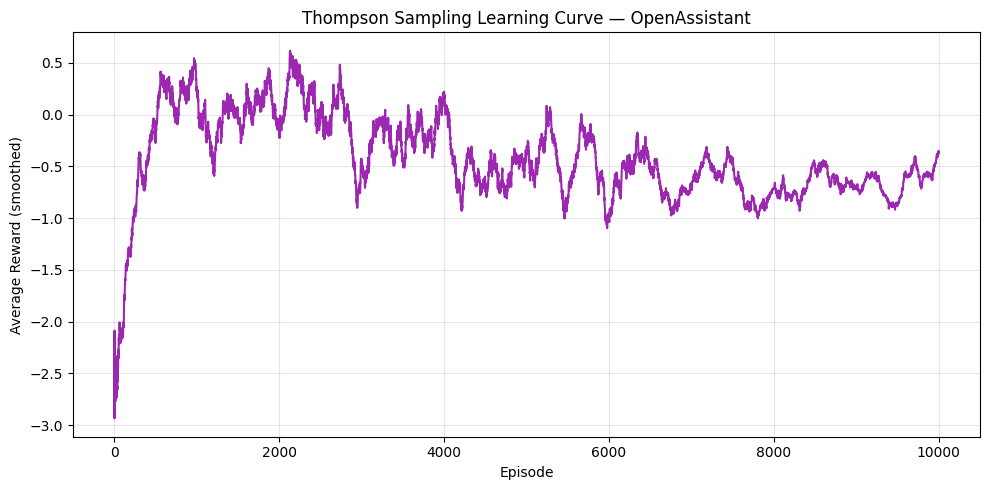

Start avg reward: -0.67
Final avg reward: -0.48


In [22]:
window = 200
smoothed = [np.mean(all_rewards[max(0,i-window):i+1]) for i in range(len(all_rewards))]

plt.figure(figsize=(10, 5))
plt.plot(smoothed, color='#9C27B0', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Average Reward (smoothed)')
plt.title('Thompson Sampling Learning Curve — OpenAssistant')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Start avg reward: {np.mean(all_rewards[:500]):.2f}')
print(f'Final avg reward: {np.mean(all_rewards[-500:]):.2f}')

## Resolution vs Escalation

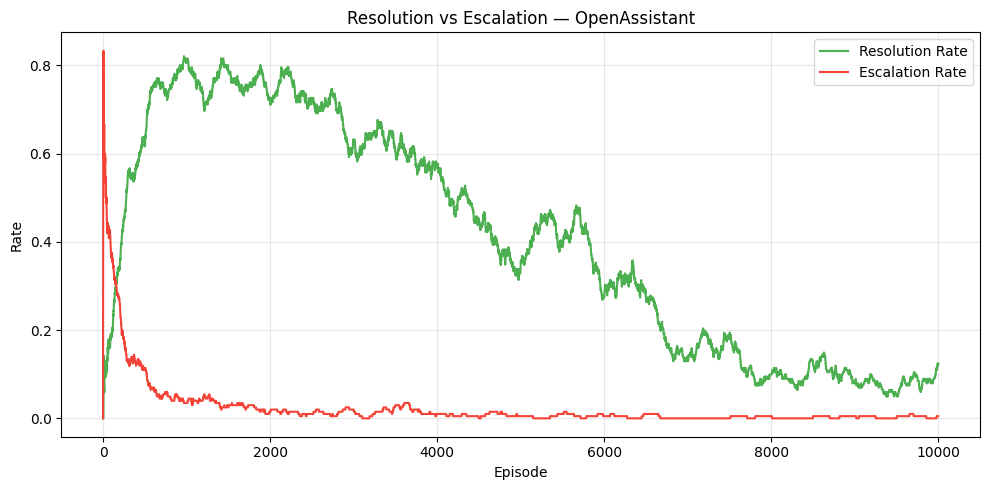

In [23]:
resolution_flags = [1 if o == 'resolved' else 0 for o in all_outcomes]
escalation_flags = [1 if o == 'escalated' else 0 for o in all_outcomes]

res_smooth = [np.mean(resolution_flags[max(0,i-window):i+1]) for i in range(len(resolution_flags))]
esc_smooth = [np.mean(escalation_flags[max(0,i-window):i+1]) for i in range(len(escalation_flags))]

plt.figure(figsize=(10, 5))
plt.plot(res_smooth, color='#4CAF50', linewidth=1.5, label='Resolution Rate')
plt.plot(esc_smooth, color='#f44336', linewidth=1.5, label='Escalation Rate')
plt.xlabel('Episode')
plt.ylabel('Rate')
plt.title('Resolution vs Escalation — OpenAssistant')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Action Preferences

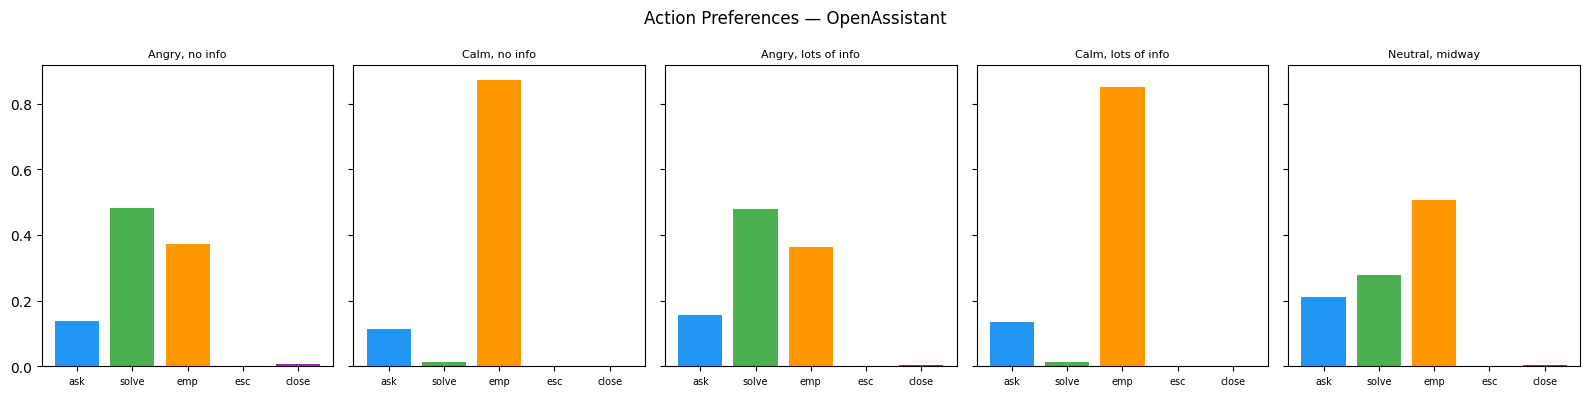

In [24]:
test_scenarios = [
    {'name': 'Angry, no info', 'state': [0.2, 0.8, 0.1, 0.1]},
    {'name': 'Calm, no info', 'state': [0.7, 0.2, 0.1, 0.1]},
    {'name': 'Angry, lots of info', 'state': [0.2, 0.8, 0.8, 0.3]},
    {'name': 'Calm, lots of info', 'state': [0.7, 0.2, 0.8, 0.3]},
    {'name': 'Neutral, midway', 'state': [0.5, 0.5, 0.5, 0.5]},
]

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#f44336', '#9C27B0']

for idx, scenario in enumerate(test_scenarios):
    state = np.array(scenario['state'])
    action_counts = np.zeros(env.NUM_ACTIONS)
    for _ in range(1000):
        a = agent.choose_action(state)
        action_counts[a] += 1
    action_counts /= 1000
    
    axes[idx].bar(range(env.NUM_ACTIONS), action_counts, color=colors)
    axes[idx].set_title(scenario['name'], fontsize=8)
    axes[idx].set_xticks(range(env.NUM_ACTIONS))
    axes[idx].set_xticklabels(['ask', 'solve', 'emp', 'esc', 'close'], fontsize=7)

fig.suptitle('Action Preferences — OpenAssistant', fontsize=12)
plt.tight_layout()
plt.show()

## Observations

*TODO: Write your observations. Some things to think about:*
- *OpenAssistant has cooperative users (low frustration). How does this affect the agent's strategy?*
- *Is the resolution rate higher here compared to Twitter/Reddit? Why?*
- *Does the agent use escalation at all with cooperative users?*

## Testing the Trained Agent

In [25]:
print('='*60)
print('TESTING — 3 sample conversations (OpenAssistant)')
print('='*60)

for test_ep in range(3):
    state = env.reset()
    total_reward = 0
    print(f'\n--- Conversation {test_ep+1} ---')
    print(f'Customer: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        total_reward += reward
        print(f'  Turn {env.turn}: [{env.ACTIONS[action]}] -> sent={next_state[0]:.2f}, frust={next_state[1]:.2f}')
        state = next_state
    
    print(f'  >> {outcome} | reward={total_reward:.2f} | turns={env.turn}')

TESTING — 3 sample conversations (OpenAssistant)

--- Conversation 1 ---
Customer: sentiment=0.52, frustration=0.31
  Turn 1: [empathize] -> sent=0.70, frust=0.21
  Turn 2: [empathize] -> sent=0.88, frust=0.11
  Turn 3: [empathize] -> sent=1.00, frust=0.01
  Turn 4: [empathize] -> sent=1.00, frust=0.00
  Turn 5: [empathize] -> sent=1.00, frust=0.00
  Turn 6: [empathize] -> sent=1.00, frust=0.00
  Turn 7: [empathize] -> sent=1.00, frust=0.00
  Turn 8: [empathize] -> sent=1.00, frust=0.00
  Turn 9: [empathize] -> sent=1.00, frust=0.00
  Turn 10: [empathize] -> sent=1.00, frust=0.00
  Turn 11: [empathize] -> sent=1.00, frust=0.00
  Turn 12: [ask_info] -> sent=0.97, frust=0.05
  Turn 13: [empathize] -> sent=1.00, frust=0.00
  Turn 14: [empathize] -> sent=1.00, frust=0.00
  Turn 15: [empathize] -> sent=1.00, frust=0.00
  >> abandoned | reward=-0.60 | turns=15

--- Conversation 2 ---
Customer: sentiment=0.55, frustration=0.19
  Turn 1: [empathize] -> sent=0.73, frust=0.09
  Turn 2: [empathiz

## Final Stats

In [26]:
test_outcomes = {'resolved': 0, 'escalated': 0, 'abandoned': 0}
test_rewards = []
test_turns = []

for _ in range(500):
    state = env.reset()
    ep_reward = 0
    while not env.done:
        action = agent.choose_action(state)
        state, reward, done, outcome = env.step(action)
        ep_reward += reward
    test_rewards.append(ep_reward)
    test_outcomes[outcome] += 1
    test_turns.append(env.turn)

print('='*50)
print('EVALUATION (500 episodes) — OpenAssistant')
print('='*50)
print(f'Avg reward:       {np.mean(test_rewards):.2f}')
print(f'Resolution rate:  {test_outcomes["resolved"]/500:.1%}')
print(f'Escalation rate:  {test_outcomes["escalated"]/500:.1%}')
print(f'Abandoned rate:   {test_outcomes["abandoned"]/500:.1%}')
print(f'Avg turns:        {np.mean(test_turns):.1f}')

EVALUATION (500 episodes) — OpenAssistant
Avg reward:       -0.67
Resolution rate:  7.4%
Escalation rate:  0.6%
Abandoned rate:   92.0%
Avg turns:        14.5


## Cross-Dataset Comparison (run this after running all 3 notebooks)

You can manually compare the final stats from all three notebooks here:

| Metric | Twitter | Reddit | OpenAssistant |
|--------|---------|--------|---------------|
| Avg Reward | ___ | ___ | ___ |
| Resolution Rate | ___ | ___ | ___ |
| Escalation Rate | ___ | ___ | ___ |
| Avg Turns | ___ | ___ | ___ |